# Tutorial de una aplicacion web de ML con Flask

Este notebook documenta el flujo completo del proyecto: seleccion del dataset Iris, analisis exploratorio, entrenamiento del modelo, optimizacion, persistencia del artefacto y validacion de la aplicacion Flask.

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import pandas as pd
from IPython.display import Image, display

from src.app import METRICS_PATH, MODEL_PATH, REPORTS_DIR, train_and_save_model
from src.utils import FEATURE_COLUMNS, TARGET_COLUMN, load_iris_dataframe, predict_species

## 1. Dataset seleccionado

Se utiliza el **UCI Iris Dataset**, disponible en scikit-learn. Es un dataset simple y clasico para clasificacion multiclase, ideal para demostrar un flujo completo de ML + Flask sin sobrecargar la interfaz web.

In [2]:
df = load_iris_dataframe()
print(df.shape)
df.head()

(150, 5)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
})

,dtype,missing_values,unique_values
sepal_length_cm,float64,0,35
sepal_width_cm,float64,0,23
petal_length_cm,float64,0,43
petal_width_cm,float64,0,22
species,str,0,3


In [4]:
df[TARGET_COLUMN].value_counts().rename_axis("species").reset_index(name="count")

,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


## 2. Entrenamiento y optimizacion

El modelo usa un pipeline con `StandardScaler` y `RandomForestClassifier`. Se compara un modelo base con una busqueda de hiperparametros mediante `GridSearchCV`.

In [5]:
results = train_and_save_model()
results["optimized_model"]["best_params"]

{'classifier__max_depth': 2,
 'classifier__min_samples_leaf': 1,
 'classifier__n_estimators': 80}

In [6]:
metric_columns = ["accuracy", "macro_f1"]
pd.DataFrame([
    {"model": "baseline", **{metric: results["baseline_model"][metric] for metric in metric_columns}},
    {"model": "optimized", **{metric: results["optimized_model"][metric] for metric in metric_columns}},
])

,model,accuracy,macro_f1
0,baseline,0.900000,0.899749
1,optimized,0.933333,0.933333


In [7]:
pd.DataFrame(
    results["optimized_model"]["confusion_matrix"],
    index=results["dataset"]["classes"],
    columns=results["dataset"]["classes"],
)

,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,1
virginica,0,1,9


## 3. Interpretacion del modelo

El Random Forest permite extraer importancia de variables para explicar que medidas aportan mas a la clasificacion.

In [8]:
pd.DataFrame(results["feature_importance"])

,feature,importance
0,petal_width_cm,0.4412
1,petal_length_cm,0.4271
2,sepal_length_cm,0.1309
3,sepal_width_cm,0.0008


## 4. Artefactos guardados

In [9]:
for path in [MODEL_PATH, METRICS_PATH, PROJECT_ROOT / "data" / "raw" / "iris.csv"]:
    print(path.relative_to(PROJECT_ROOT), path.exists())

models\iris_classifier.joblib True
models\iris_metrics.json True
data\raw\iris.csv True


## 5. Prueba de inferencia

La misma funcion usada por Flask se prueba aqui con un ejemplo numerico.

In [10]:
artifact = joblib.load(MODEL_PATH)
sample = {
    "sepal_length_cm": 5.8,
    "sepal_width_cm": 3.0,
    "petal_length_cm": 4.3,
    "petal_width_cm": 1.3,
}
predict_species(artifact, sample)

{'prediction': 'versicolor',
 'probabilities': {np.str_('setosa'): 0.0099,
  np.str_('versicolor'): 0.9179,
  np.str_('virginica'): 0.0722}}

## 6. Validacion de Flask

Se valida la app sin abrir navegador usando el cliente de pruebas de Flask.

In [11]:
from app import app

with app.test_client() as client:
    health = client.get("/health")
    response = client.post("/", data=sample)

print("health:", health.status_code, health.json)
print("prediction page:", response.status_code)

health: 200 {'model_available': True, 'status': 'ok'}
prediction page: 200


## 7. Visualizaciones

species_distribution.png


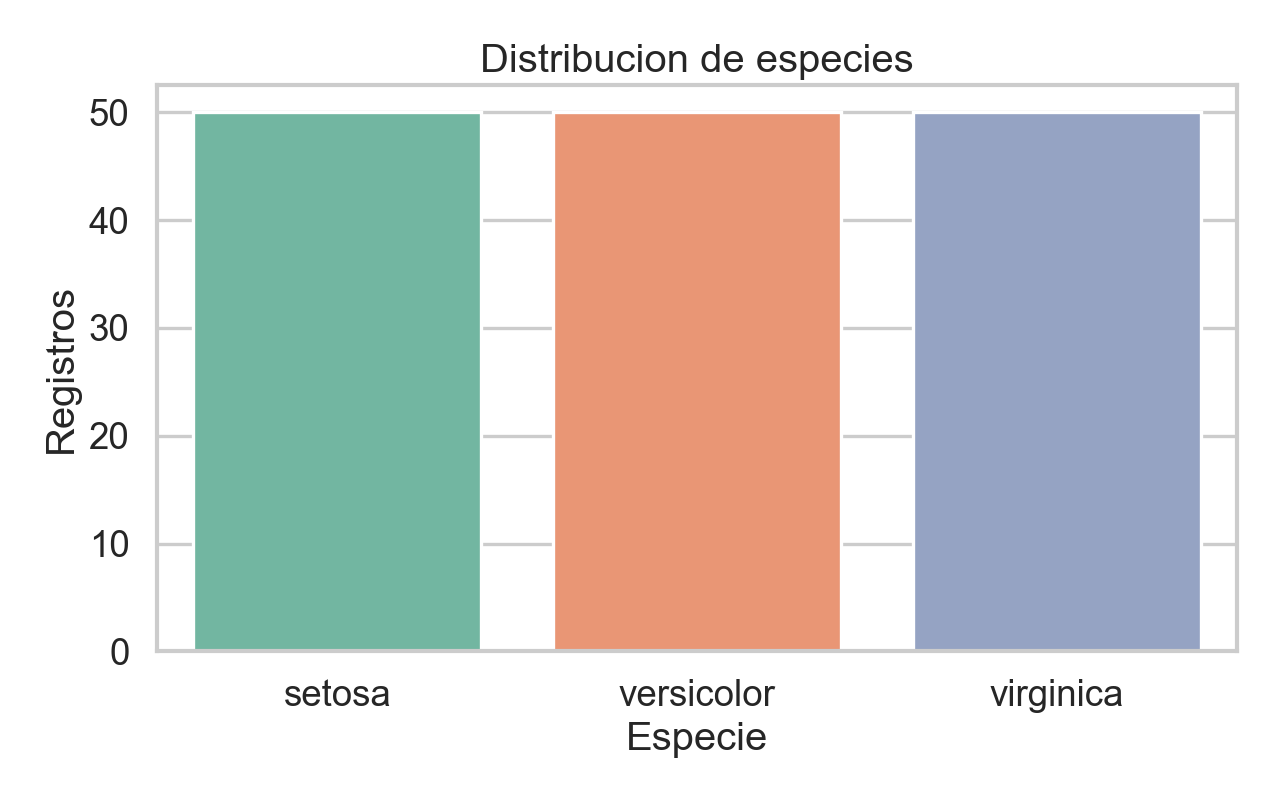

feature_importance.png


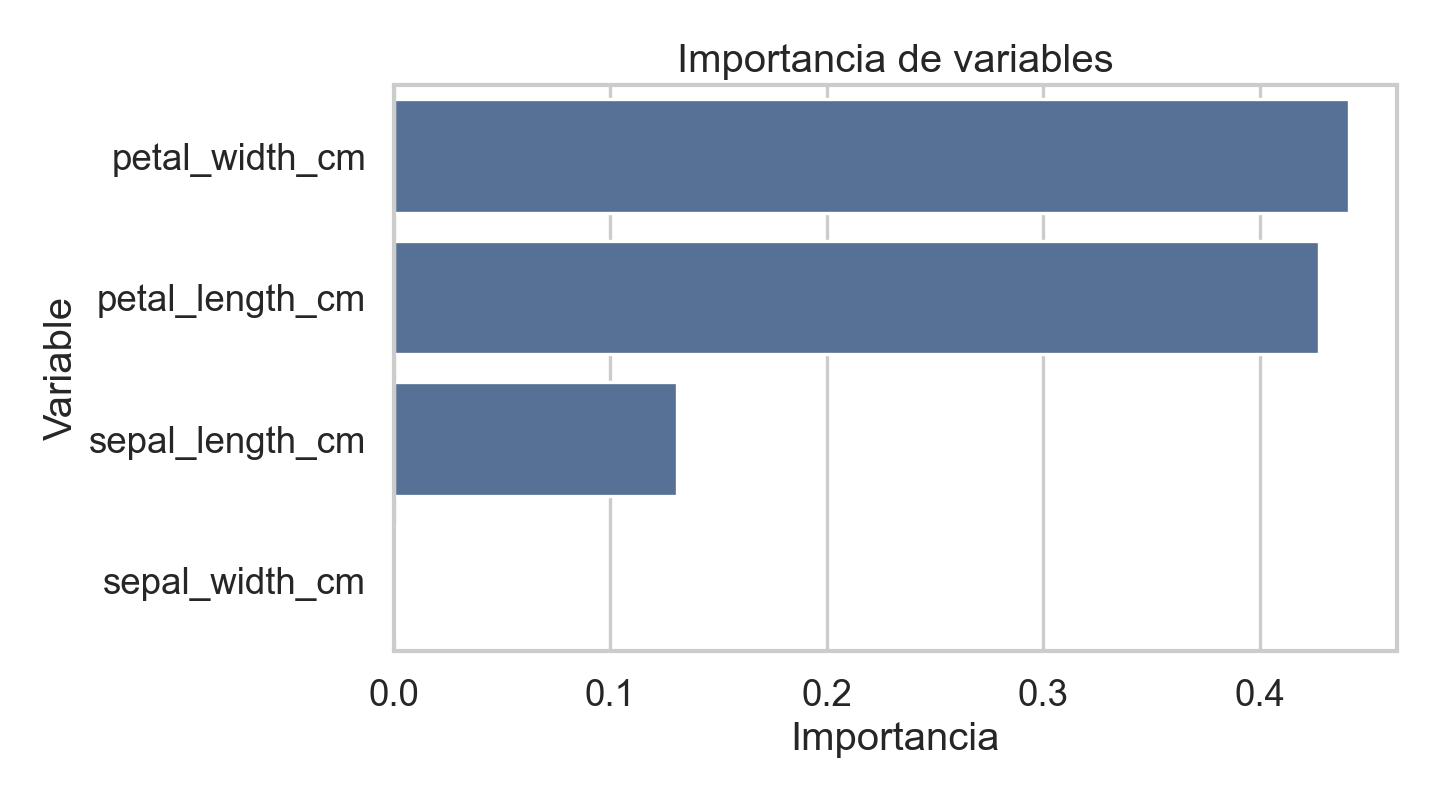

petal_scatter.png


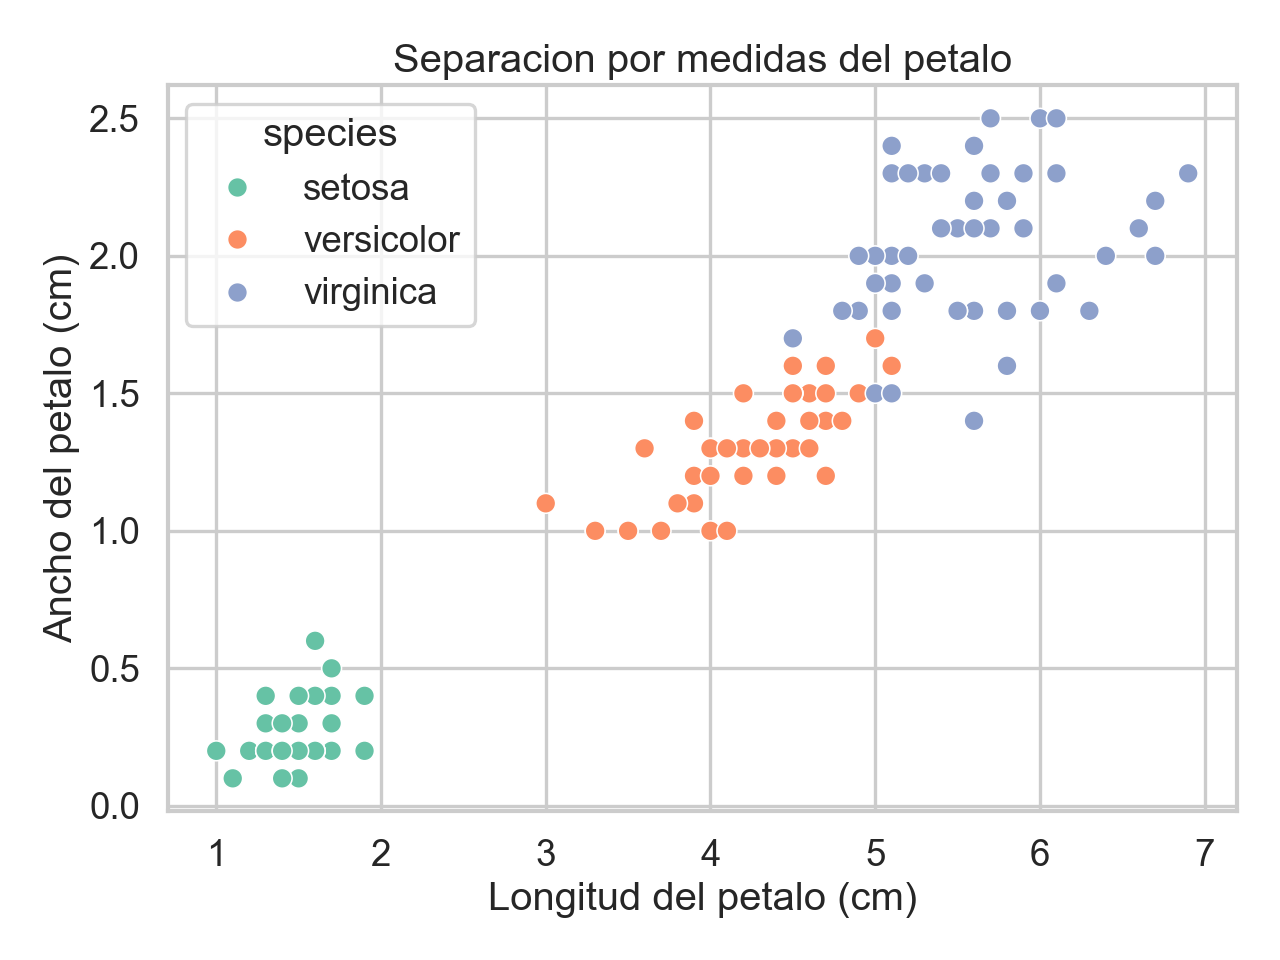

app_banner.png


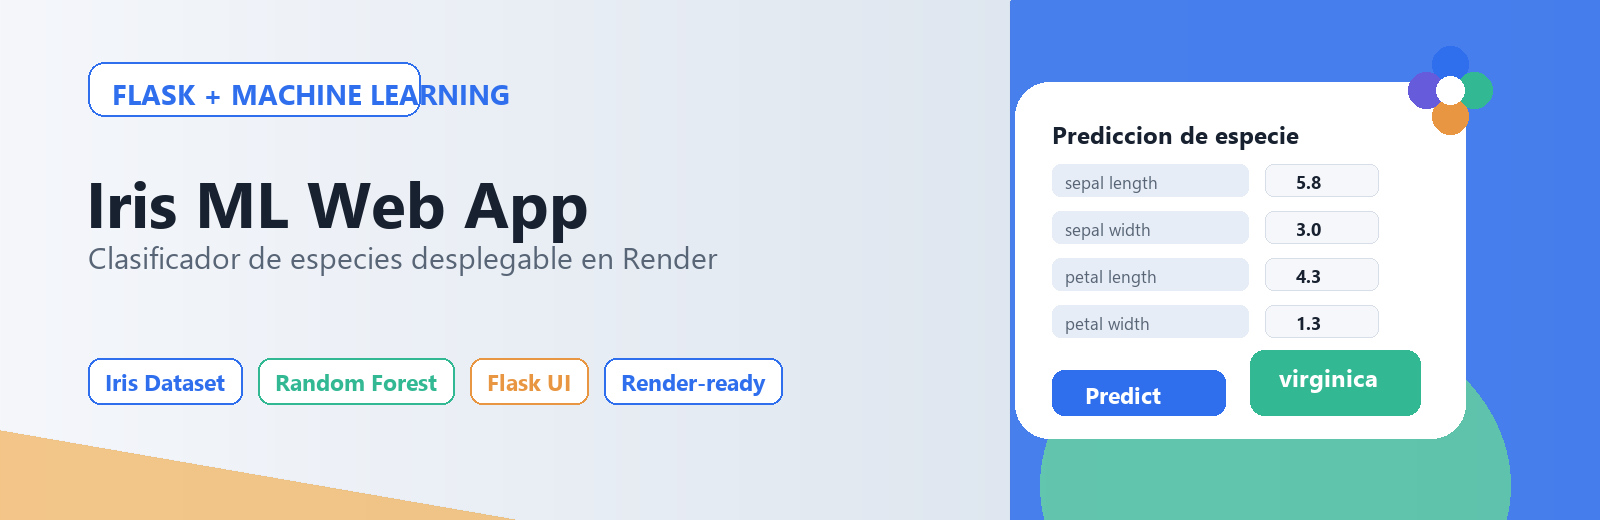

In [12]:
for figure in ["species_distribution.png", "feature_importance.png", "petal_scatter.png", "app_banner.png"]:
    print(figure)
    display(Image(filename=str(REPORTS_DIR / figure)))